# Structure-head entropy diversity ablation

This notebook compares training loss, entropy, and sampled topological diversity for three structure-head entropy weights. Expensive Comet downloads and topology generation are cached; the final publication figure can be regenerated without loading checkpoints again.

In [1]:
# Comet credentials
COMET_API_KEY = "o77J6VCMDamustkfJuMXZ2jdV"
COMET_WORKSPACE = "maurice-filo"

# Each entry becomes one row in the final figure. The newest experiment is selected from each project.
RUNS = [
    {
        "label": "Full structure entropy",
        "checkpoint": "apps/run-full-3.pkl",
        "comet_project": "logic-circuit-ablation-full",
        "structure_entropy_weight": 2.0,
        "color": "#0072B2",
    },
    {
        "label": "Structure entropy weight = 1.0",
        "checkpoint": "apps/run-low_structure_entropy-1.pkl",
        "comet_project": "logic-circuit-ablation-low-structure-entropy",
        "structure_entropy_weight": 1.0,
        "color": "#009E73",
    },
    {
        "label": "Structure entropy weight = 0.1",
        "checkpoint": "apps/run-lower_structure_entropy-1.pkl",
        "comet_project": "logic-circuit-ablation-lower-structure-entropy",
        "structure_entropy_weight": 0.1,
        "color": "#D55E00",
    },
]

# Comet metrics used in columns one and two.
LOSS_METRIC = "Loss: Batch Best"
ENTROPY_METRIC = "Entropy: Batch"

# Fresh policy sampling used for the topology-diversity column.
DEVICE = "auto"
N_SAMPLES = 1280
SAMPLE_HOF_SIZE = 1280
TOPOLOGY_DISTANCE_THRESHOLD = 4
REGENERATE_TOPOLOGIES = False  # True reruns checkpoint sampling; False reuses cached NetworkX graphs
REFRESH_COMET_METRICS = False   # True downloads newest Comet metrics; False reuses cached CSVs

# Local cache and output.
CACHE_DIR = "apps/ablation_logic_circuits/structure_entropy_diversity_data"
USE_LOG_LOSS = True
USE_LOG_ENTROPY = False

In [2]:
from pathlib import Path
import gc
import pickle
import sys
from typing import Any

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from comet_ml import API


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "RL4CRN").is_dir() and (candidate / "apps").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing RL4CRN/ and apps/.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from RL4CRN.utils.input_interface import load_session_and_trainer
from RL4CRN.utils.default_tasks.LogicTaskKind import LogicTaskKind  # registers the logic task kind
from RL4CRN.utils.visualizations import build_hamming_graph

cache_dir = REPO_ROOT / CACHE_DIR
cache_dir.mkdir(parents=True, exist_ok=True)
workspace = COMET_WORKSPACE

In [3]:
def resolve_checkpoint(path: str) -> Path:
    candidate = Path(path)
    if not candidate.is_absolute():
        candidate = REPO_ROOT / candidate
    return candidate.resolve()


checkpoint_rows = []
for run in RUNS:
    checkpoint = resolve_checkpoint(run["checkpoint"])
    checkpoint_rows.append(
        {
            "label": run["label"],
            "checkpoint": str(checkpoint),
            "exists": checkpoint.exists(),
        }
    )

checkpoint_validation = pd.DataFrame(checkpoint_rows)
display(checkpoint_validation)

missing = checkpoint_validation.loc[~checkpoint_validation["exists"], "checkpoint"].tolist()
if missing:
    raise FileNotFoundError("Missing checkpoint(s):\n" + "\n".join(missing))

,label,checkpoint,exists
0,Full structure entropy,/local0/home/mfilo/git/GenAI-Net/apps/run-full...,True
1,Structure entropy weight = 1.0,/local0/home/mfilo/git/GenAI-Net/apps/run-low_...,True
2,Structure entropy weight = 0.1,/local0/home/mfilo/git/GenAI-Net/apps/run-lowe...,True


In [4]:
def experiment_name(experiment) -> str:
    name = getattr(experiment, "name", None)
    if name:
        return str(name)
    getter = getattr(experiment, "get_name", None)
    return str(getter() if callable(getter) else experiment.key)


def safe_name(value: str) -> str:
    return "_".join(value.replace(":", "").split())


def metric_cache_path(run: dict[str, Any], metric_name: str) -> Path:
    return cache_dir / f"{safe_name(run['comet_project'])}__{safe_name(metric_name)}.csv"


def select_experiment(api, run: dict[str, Any]):
    experiments = list(
        api.get_experiments(
            workspace,
            run["comet_project"],
            sort_by="startTime",
            sort_order="desc",
        )
    )
    if not experiments:
        raise ValueError(f"No experiments found in Comet project {run['comet_project']!r}.")
    return experiments[0]


def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    return next((column for column in candidates if column in df.columns), None)


def download_metric(experiment, metric_name: str) -> pd.DataFrame:
    records = experiment.get_metrics(metric_name) or []
    df = pd.DataFrame(records)

    if df.empty:
        df = experiment.get_metric_total_df(metric_name)
        df = pd.DataFrame() if df is None else df

    if df.empty:
        raise ValueError(f"Metric {metric_name!r} is missing from {experiment_name(experiment)}.")

    step_column = first_existing_column(df, ["step", "global_step", "x"])
    value_column = first_existing_column(df, ["metricValue", "value", "metric_value"])
    if value_column is None:
        raise ValueError(f"No value column found for {metric_name!r}: {list(df.columns)}")
    if step_column is None:
        df["step"] = np.arange(len(df))
        step_column = "step"

    normalized = pd.DataFrame(
        {
            "step": pd.to_numeric(df[step_column], errors="coerce"),
            "value": pd.to_numeric(df[value_column], errors="coerce"),
        }
    )
    return normalized.dropna().sort_values("step")


metric_data = {}
selected_experiments = []
api = None
for run in RUNS:
    metric_data[run["label"]] = {}
    experiment = None
    for metric_name in [LOSS_METRIC, ENTROPY_METRIC]:
        cache_path = metric_cache_path(run, metric_name)
        if cache_path.exists() and not REFRESH_COMET_METRICS:
            metric_df = pd.read_csv(cache_path)
            source = "cache"
        else:
            if api is None:
                api = API(api_key=COMET_API_KEY)
            if experiment is None:
                experiment = select_experiment(api, run)
            metric_df = download_metric(experiment, metric_name)
            metric_df.to_csv(cache_path, index=False)
            source = experiment_name(experiment)
        metric_data[run["label"]][metric_name] = metric_df
        selected_experiments.append(
            {"label": run["label"], "metric": metric_name, "source": source, "points": len(metric_df)}
        )

display(pd.DataFrame(selected_experiments))

,label,metric,source,points
0,Full structure entropy,Loss: Batch Best,cache,400
1,Full structure entropy,Entropy: Batch,cache,400
2,Structure entropy weight = 1.0,Loss: Batch Best,cache,400
3,Structure entropy weight = 1.0,Entropy: Batch,cache,400
4,Structure entropy weight = 0.1,Loss: Batch Best,cache,400
5,Structure entropy weight = 0.1,Entropy: Batch,cache,400


In [5]:
def topology_graph_cache_path(run: dict[str, Any]) -> Path:
    return cache_dir / f"{safe_name(run['comet_project'])}__topology_graph.nx.pkl"


def build_topology_networkx_graph(run: dict[str, Any], sampled_crns: list[Any], rewards: np.ndarray) -> nx.Graph:
    signatures = np.stack([crn.get_bool_signature() for crn in sampled_crns]).astype(bool)
    sparse_graph = build_hamming_graph(
        signatures,
        perf=None,
        alpha=0.0,
        t=TOPOLOGY_DISTANCE_THRESHOLD,
        k=None,
    )
    graph = nx.from_scipy_sparse_array(sparse_graph, create_using=nx.Graph)

    for node in graph.nodes:
        graph.nodes[node]["signature"] = signatures[node]
        graph.nodes[node]["loss"] = float(rewards[node])
        graph.nodes[node]["count"] = 1

    for u, v, edge_data in graph.edges(data=True):
        structural_distance = float(edge_data.get("weight", 1.0))
        loss_delta = abs(float(rewards[u]) - float(rewards[v]))
        weighted_distance = structural_distance * (1.0 + 10.0 * loss_delta)
        edge_data["structural_distance"] = structural_distance
        edge_data["loss_delta"] = loss_delta
        edge_data["weighted_distance"] = weighted_distance
        edge_data["attraction"] = 1.0 / (weighted_distance + 1e-6)

    communities = (
        nx.community.greedy_modularity_communities(graph, weight="attraction")
        if graph.number_of_edges()
        else [{node} for node in graph.nodes]
    )
    for community_id, community_nodes in enumerate(communities):
        for node in community_nodes:
            graph.nodes[node]["community"] = community_id

    positions = nx.spring_layout(
        graph,
        seed=42,
        weight="attraction",
        k=1.5 / np.sqrt(len(graph.nodes) + 1),
        iterations=100,
    )
    for node, position in positions.items():
        graph.nodes[node]["pos"] = np.asarray(position, dtype=float)

    graph.graph.update(
        {
            "label": run["label"],
            "checkpoint": str(resolve_checkpoint(run["checkpoint"])),
            "comet_project": run["comet_project"],
            "structure_entropy_weight": float(run["structure_entropy_weight"]),
            "requested_samples": int(N_SAMPLES),
            "unique_topologies": int(len(sampled_crns)),
            "distance_threshold": int(TOPOLOGY_DISTANCE_THRESHOLD),
            "best_loss": float(rewards.min()),
            "worst_loss": float(rewards.max()),
            "layout": "spring",
            "layout_seed": 42,
        }
    )
    return graph


topology_graphs = {}
sample_summaries = []

for run in RUNS:
    label = run["label"]
    graph_path = topology_graph_cache_path(run)
    checkpoint = resolve_checkpoint(run["checkpoint"])
    cache_is_fresh = graph_path.exists() and graph_path.stat().st_mtime >= checkpoint.stat().st_mtime

    if cache_is_fresh and not REGENERATE_TOPOLOGIES:
        print(f"Using cached NetworkX graph: {label}")
        with graph_path.open("rb") as fh:
            graph = pickle.load(fh)
    else:
        print(f"Loading and sampling once: {label} -> {checkpoint.name}")
        trainer = load_session_and_trainer(str(checkpoint), device=DEVICE)
        sample_hof = trainer.sample(n_samples=N_SAMPLES, sample_hof_size=SAMPLE_HOF_SIZE)
        sampled_crns = [env.state for env in sample_hof]
        rewards = np.asarray([crn.last_task_info.get("reward", np.inf) for crn in sampled_crns])

        valid = np.isfinite(rewards)
        sampled_crns = [crn for crn, keep in zip(sampled_crns, valid) if keep]
        rewards = rewards[valid]
        if not sampled_crns:
            raise ValueError(f"Sampling produced no valid CRNs for {label}.")

        order = np.argsort(rewards)
        sampled_crns = [sampled_crns[i] for i in order]
        rewards = rewards[order]
        graph = build_topology_networkx_graph(run, sampled_crns, rewards)

        with graph_path.open("wb") as fh:
            pickle.dump(graph, fh, protocol=pickle.HIGHEST_PROTOCOL)

        del trainer, sample_hof, sampled_crns, rewards
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    expected_weight = float(run["structure_entropy_weight"])
    if graph.graph.get("structure_entropy_weight") != expected_weight:
        graph.graph["structure_entropy_weight"] = expected_weight
        with graph_path.open("wb") as fh:
            pickle.dump(graph, fh, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"Updated cached structure entropy weight: {label} -> {expected_weight:g}")

    topology_graphs[label] = graph
    sample_summaries.append(
        {
            "label": label,
            "structure_entropy_weight": graph.graph["structure_entropy_weight"],
            "unique_topologies": graph.number_of_nodes(),
            "edges": graph.number_of_edges(),
            "best_loss": graph.graph["best_loss"],
            "graph_cache": str(graph_path),
        }
    )

diversity_summary = pd.DataFrame(sample_summaries)
display(diversity_summary)


Using cached NetworkX graph: Full structure entropy
Using cached NetworkX graph: Structure entropy weight = 1.0
Using cached NetworkX graph: Structure entropy weight = 0.1


,label,structure_entropy_weight,unique_topologies,edges,best_loss,graph_cache
0,Full structure entropy,2.0,917,32926,0.007643,/local0/home/mfilo/git/GenAI-Net/apps/ablation...
1,Structure entropy weight = 1.0,1.0,426,66952,0.026748,/local0/home/mfilo/git/GenAI-Net/apps/ablation...
2,Structure entropy weight = 0.1,0.1,31,460,0.002296,/local0/home/mfilo/git/GenAI-Net/apps/ablation...


Saved: /local0/home/mfilo/git/GenAI-Net/apps/ablation_logic_circuits/figures/logic-circuit-ablation-full__topology.pdf


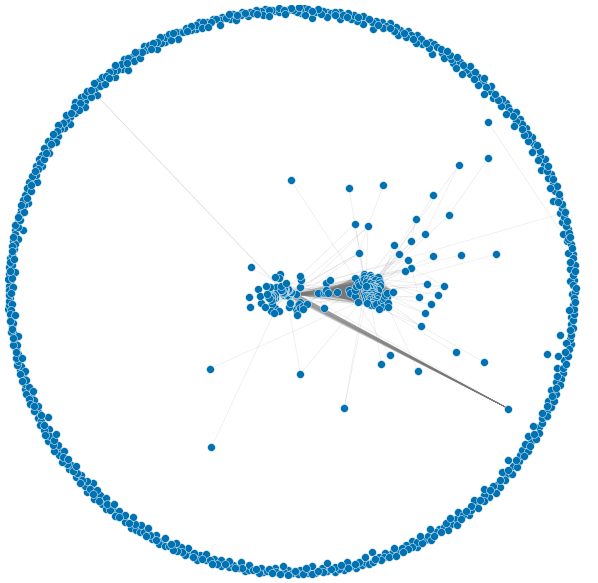

Saved: /local0/home/mfilo/git/GenAI-Net/apps/ablation_logic_circuits/figures/logic-circuit-ablation-low-structure-entropy__topology.pdf


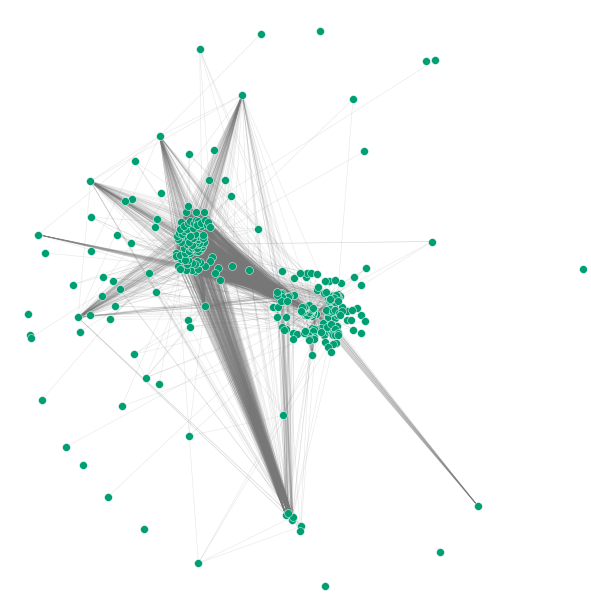

Saved: /local0/home/mfilo/git/GenAI-Net/apps/ablation_logic_circuits/figures/logic-circuit-ablation-lower-structure-entropy__topology.pdf


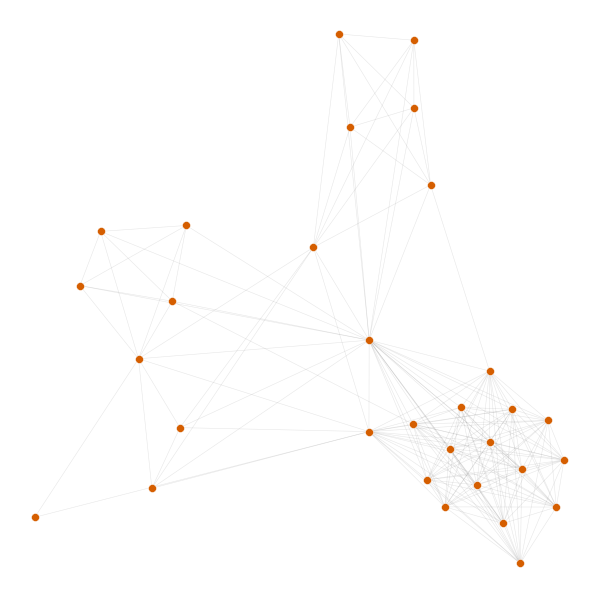

Saved: /local0/home/mfilo/git/GenAI-Net/apps/ablation_logic_circuits/figures/structure_entropy_weight_vs_unique_topologies.pdf


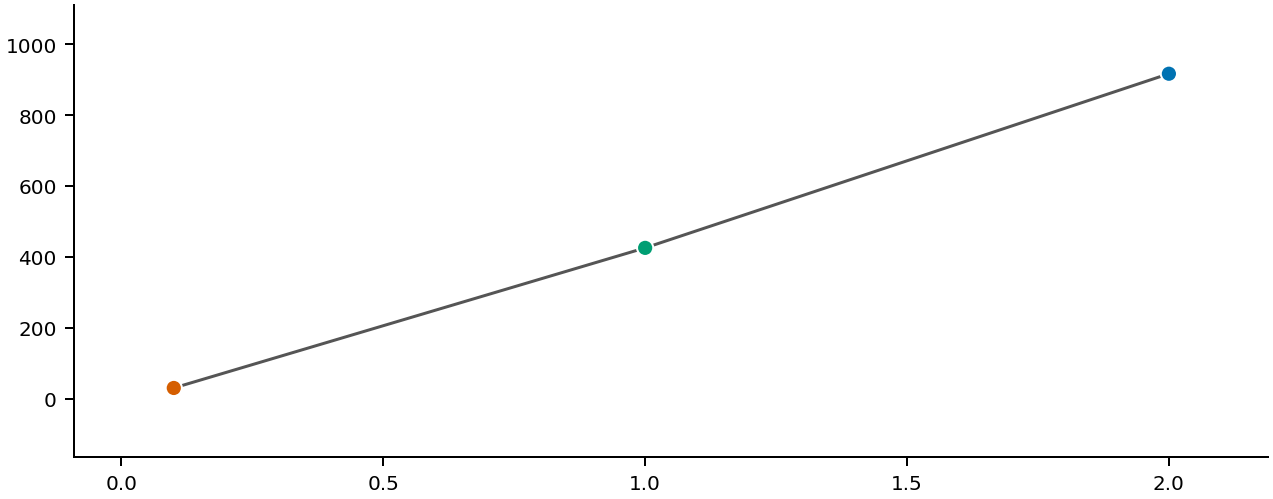

In [6]:
# Replot freely from topology_graphs without loading checkpoints again.
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "semibold",
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.25,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": 180,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.03,
    }
)

figures_dir = REPO_ROOT / "apps/ablation_logic_circuits/figures"
figures_dir.mkdir(parents=True, exist_ok=True)

DISPLAY_EDGE_DISTANCE = 3


def plot_saved_topology_graph(graph: nx.Graph, node_color: str, figsize=(3.35, 3.35)):
    nodes = list(graph.nodes)
    display_graph = nx.Graph()
    display_graph.add_nodes_from(nodes)
    display_graph.add_edges_from(
        (u, v, data)
        for u, v, data in graph.edges(data=True)
        if data.get("structural_distance", np.inf) < DISPLAY_EDGE_DISTANCE
    )

    positions = nx.spring_layout(
        display_graph,
        seed=42,
        weight="attraction",
        k=4.0 / np.sqrt(max(display_graph.number_of_nodes(), 1)),
        iterations=300,
        threshold=1e-5,
        scale=1.0,
    )
    position_array = np.asarray([positions[node] for node in nodes])
    spans = np.ptp(position_array, axis=0)
    spans[spans == 0] = 1.0
    position_array = 2.0 * (position_array - position_array.min(axis=0)) / spans - 1.0
    positions = {node: position_array[index] for index, node in enumerate(nodes)}

    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    nx.draw_networkx_edges(
        display_graph,
        positions,
        ax=ax,
        edge_color="#777777",
        width=0.22,
        alpha=0.18,
    )
    nx.draw_networkx_nodes(
        display_graph,
        positions,
        ax=ax,
        node_size=10,
        node_color=node_color,
        edgecolors="white",
        linewidths=0.18,
    )
    ax.set_aspect("equal")
    ax.margins(0.005)
    ax.set_axis_off()
    return fig


# Three independent topology figures.
for run in RUNS:
    label = run["label"]
    graph = topology_graphs[label]
    fig = plot_saved_topology_graph(graph, run["color"])
    figure_path = figures_dir / f"{safe_name(run['comet_project'])}__topology.pdf"
    fig.savefig(figure_path, format="pdf", dpi=600, bbox_inches="tight")
    print(f"Saved: {figure_path}")
    plt.show()
    plt.close(fig)


# Structure-head entropy weight versus sampled unique-topology count.
count_df = diversity_summary.sort_values(["structure_entropy_weight", "label"]).reset_index(drop=True)

color_by_label = {run["label"]: run["color"] for run in RUNS}
point_colors = count_df["label"].map(color_by_label)

fig, ax = plt.subplots(figsize=(7.1, 2.8), layout="constrained")
ax.plot(
    count_df["structure_entropy_weight"],
    count_df["unique_topologies"],
    color="#555555",
    linewidth=1.2,
    zorder=1,
)
ax.scatter(
    count_df["structure_entropy_weight"],
    count_df["unique_topologies"],
    s=42,
    c=point_colors,
    edgecolors="white",
    linewidths=0.8,
    zorder=2,
)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.grid(False)
ax.margins(x=0.10, y=0.22)
ax.spines[["top", "right"]].set_visible(False)

count_figure_path = figures_dir / "structure_entropy_weight_vs_unique_topologies.pdf"
fig.savefig(count_figure_path, format="pdf", dpi=600, bbox_inches="tight")
print(f"Saved: {count_figure_path}")
plt.show()
